In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import UnknownTruncationMultivariateNormalNLL
from delphi.oracle import UnknownGaussian
from delphi.oracle import oracle
from delphi.distributions import Exp_h
from delphi.utils.helpers import cov

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from torch.distributions import MultivariateNormal

ch.set_default_dtype(ch.double)

In [874]:
def unknown_trunc_nll(phi, exp_h, v, T, data, dims=1):
#     T = ch.inverse(Sigma)
#     v = T @ mu
    T.requires_grad, v.requires_grad = True, True
    theta = ch.cat([T.flatten(), v])
    loss = UnknownTruncationMultivariateNormalNLL.apply(
        theta, data, phi, exp_h, dims,
    )
    if loss.size(0) > 1: loss = loss.sum(0, keepdim=True)
    loss.backward()
    return loss, T.grad, v.grad

In [552]:
class UnknownTruncationMultivariateNormalNLL(ch.autograd.Function):
    """
    Computes the negative population log likelihood for truncated multivariate normal distribution with unknown truncation.
    Calculates the population log-likelihood for the current batch in the forward step, and 
    then calculates its gradient in the backwards step.
    """
    @staticmethod
    def forward(ctx, theta, data, phi, exp_h, dims):
        """
        Args: 
            params (torch.Tensor): size (dims + dims ** 2,) - current reparameterized mean and covariance matrix estimates concatenated together
            data: (torch.Tensor): size() - precomupted gradient values for both the mean and covariance matrix
            u (torch.Tensor): size (dims,) - current reparameterized mean estimate
            B (torch.Tensor): size (dims, dims) - current reparameterized covariance matrix estimate
            x (torch.Tensor): size (batch_size, dims) - batch of dataset samples 
            pdf (torch.Tensor): size (batch_size, 1) - batch of pdf for dataset samples
            loc_grad (torch.Tensor): (batch_size, dims) - precomputed gradient for mean for batch
            cov_grad (torch.Tensor): (batch_size, dims * dims) - precomputed gradient for covariance matrix for batch 
            phi (oracle.UnknownGaussian): oracle object for learning truncation set 
            exp_h (Exp_h): helper class object for calculating exponential in the gradient
            dims (int): the dimension number 
            known_cov (bool): whether the covariance matrix is known; if so, provide 0 as gradient for covariance matrix
        """
        T = theta[:dims**2].view(dims, dims)
        v = theta[dims**2:]
        x = data[:,:dims].view(data.size(0), dims)
        pdf = data[:,dims][...,None]
        loc_grad = data[:,dims+1:dims+dims+1].view(data.size(0), dims)
        cov_grad = data[:,dims+dims+1:].view(data.size(0), dims, dims)
        exp = exp_h(v, T, x)
        psi = phi.psi_k(x)
        loss = exp * pdf * psi
        ctx.save_for_backward(loss, loc_grad, cov_grad)
        ctx.dims = dims
        return loss / data.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        loss, loc_grad, cov_grad = ctx.saved_tensors
        term_one = loc_grad * loss
        term_two = cov_grad.flatten(1) * loss
        return ch.cat([term_two, term_one], dim=1) / cov_grad.size(0), None, None, None, None, None

In [701]:
class Exp_h:
    def __init__(self, emp_loc, emp_cov):
        self.emp_loc = emp_loc
        self.emp_cov = emp_cov
        self.pi_const = (self.emp_loc.size(0) / 2.0) * ch.log(ch.Tensor([2.0 * ch.pi])).unsqueeze(0)

    def __call__(self, u, B, x):
        """returns: evaluates exponential function"""
        quad_term = 0.5 * ch.sum(x @ B * x, dim=1, keepdim=True)
        trace_term = ch.trace((B - ch.eye(u.size(0))) @ (self.emp_cov + self.emp_loc[...,None] @ self.emp_loc[None,...])).unsqueeze(0)/2.0
        lin_term = ((x - self.emp_loc) @ u)[..., None]
        h = quad_term - trace_term - lin_term + self.pi_const
        return ch.exp(h).double()

In [809]:
import math
class UnknownGaussian(oracle):
    def __init__(self, 
                 k, 
                 S):
        self.emp_loc = S.mean(0)
        self.emp_covariance_matrix = cov(S)

        self._emp_dist = MultivariateNormal(self.emp_loc, self.emp_covariance_matrix)
        self._d = int(S.shape[1])
        self._k = k
        self._factorials = ch.tensor([math.factorial(i) for i in range(k + 1)], dtype=ch.float32)

        self.multi_indices = self._generate_multi_indices(self._k)
        self._norm_const = self._compute_norm_constants()

        self._C_v = self._compute_hermite_coefficients(S)

        self._dist = None

    def _generate_multi_indices(self, k):
        # For d=1 this returns [[0],[1],...,[k]]
        from itertools import product
        indices = []
        for degree in range(k + 1):
            for combo in product(range(degree + 1), repeat=self._d):
                if sum(combo) == degree:
                    indices.append(list(combo))
        return ch.tensor(indices, dtype=ch.long)

    def _hermite_polynomial_1d(self, z, degree):
        """Probabilist's Hermite He_n(z) computed via stable recurrence."""
        if degree == 0:
            return ch.ones_like(z)
        elif degree == 1:
            return z
        else:
            He_prev_prev = ch.ones_like(z)
            He_prev = z
            for n in range(2, degree + 1):
                He_curr = z * He_prev - (n - 1) * He_prev_prev
                He_prev_prev, He_prev = He_prev, He_curr
            return He_prev

    def H_v(self, x):
        """
        Evaluate multivariate Hermite polynomials *at standardized inputs*.
        For univariate: z = (x - emp_loc) / sqrt(emp_var).
        Returns tensor shape (n, num_indices).
        """
        n = x.shape[0]
        num_indices = len(self.multi_indices)
        result = ch.ones(n, num_indices, dtype=x.dtype, device=x.device)

        # Standardize: for each dim use emp_loc and emp_covariance_matrix diag
        # For univariate:
        if self._d == 1:
            var = self.emp_covariance_matrix.reshape(-1)[0] if self.emp_covariance_matrix.numel() == 1 else self.emp_covariance_matrix[0,0]
            std = ch.sqrt(var)
            z = (x[:, 0] - self.emp_loc[0]) / (std + 1e-12)   # (n,)
            for idx, V in enumerate(self.multi_indices):
                deg = int(V[0].item())
                He = self._hermite_polynomial_1d(z, deg)      # (n,)
                # Normalize by sqrt(deg!) so basis is orthonormal under N(0,1)
                if deg > 0:
                    He = He / ch.sqrt(self._factorials[deg])
                result[:, idx] = He.flatten()
            return result

        for idx, V in enumerate(self.multi_indices):
            prod = ch.ones(n, dtype=x.dtype, device=x.device)
            for dim in range(self._d):
                degree = int(V[dim].item())
                if degree > 0:
                    # standardize dimension
                    var = self.emp_covariance_matrix[dim, dim]
                    std = ch.sqrt(var)
                    z = (x[:, dim] - self.emp_loc[dim]) / (std + 1e-12)
                    prod = prod * He
            # Normalize by sqrt(V!) = sqrt(prod of factorials) ONCE
            V_factorial = ch.prod(self._factorials[V.long()])
            result[:, idx] = prod / ch.sqrt(V_factorial)
        return result

    def _compute_hermite_coefficients(self, S):
        """
        Compute c_v = E_D[H_V(z)] where H_V evaluated at standardized samples from S.
        S should be samples *from the truncated set* (i.e., only samples x in S).
        """
        H_vals = self.H_v(S)   # shape (n, num_indices)
        return H_vals.mean(dim=0)

    def psi_k(self, x):
        """
        Evaluate psi approximation on x (tensor shape (n,d)).
        Returns (n, 1) tensor with values ~[0,1].
        """
        H_vals = self.H_v(x)                      # (n, num_indices)
        expansion = (self._C_v * H_vals).sum(dim=1)   # (n,)
        return ch.clamp(expansion, min=0)[...,None]
    
    def _compute_norm_constants(self):
        """Compute sqrt(V!) for each multi-index V."""
        norms = []
        for V in self.multi_indices:
            # V! = product of v_i! for each component
            V_factorial = ch.prod(self._factorials[V.long()])
            norms.append(ch.sqrt(V_factorial.float()))
        return ch.tensor(norms)

    def __call__(self, x):
        if self._dist is None:
            raise Exception("must learn underlying distribution for membership oracle")
        
        ratio = ch.exp(unknown_gaussian_oracle._emp_dist.log_prob(x) - unknown_gaussian_oracle._dist.log_prob(x))[:,None]
        psi_ = unknown_gaussian_oracle.psi_k(x)
        return ((ratio * unknown_gaussian_oracle.psi_k(x)) > 0.5).float()

    @property
    def emp_dist(self):
        return self._emp_dist

    @property
    def dist(self):
        return self._dist

    @dist.setter
    def dist(self, dist_):
        self._dist = dist_

    @property
    def C_v(self):
        return self._C_v

    @property
    def norm_const(self):
        return self._norm_const

    @property
    def d(self):
        return self._d

    def __str__(self): 
        return 'unknown gaussian'

In [703]:
import time

def generate_data(phi, num_samples, M, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
        
    S = ch.Tensor([])
    X = ch.Tensor([])
    sampled = 0
    while S.size(0) < num_samples:
        
        samples = M.sample([num_samples])
        
        trunc_indices = phi(samples).flatten().nonzero().flatten()

        S = ch.cat([S, samples[trunc_indices]])
        X = ch.cat([X, samples])
        sampled += num_samples

    alpha = S.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return S[:num_samples], alpha, X 

alpha: 0.495
Data diagnostics:
S shape: torch.Size([10000, 1])
S range: [-1.561, 3.000]
S mean: 2.193 (true μ=1.0)
S std: 0.614 (true σ=1.0)
Samples above 1: 9520/10000
Samples below 1: 480/10000


<IPython.core.display.Javascript object>


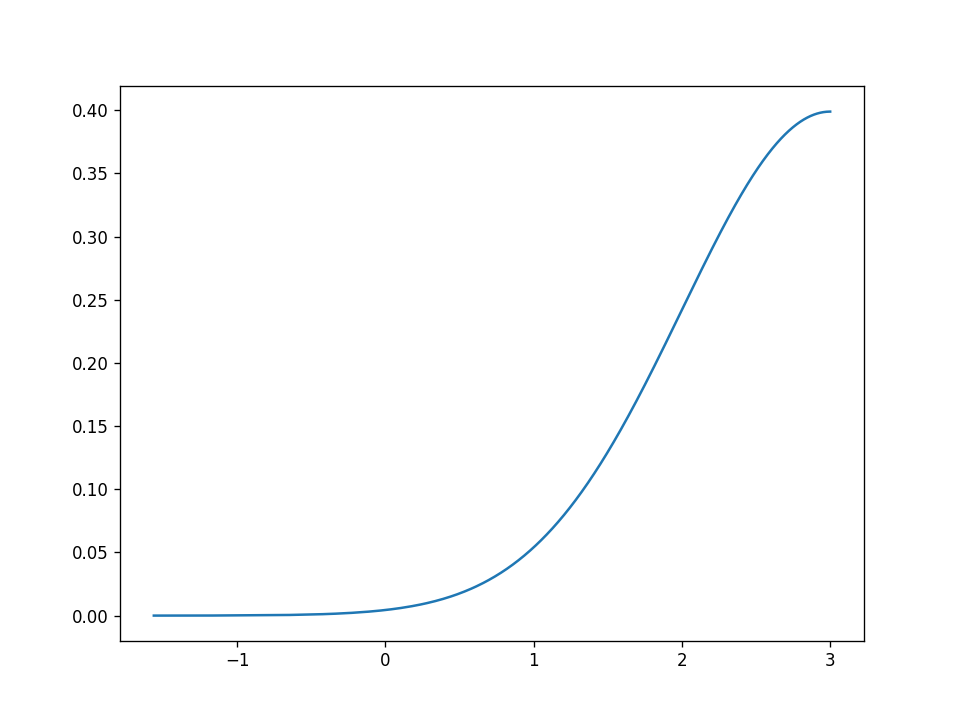

In [704]:
from torch.distributions import MultivariateNormal

def phi(x):
    return x[:,0] < 3


D = 1
num_samples = 10000
M = MultivariateNormal(3*ch.ones(D), ch.eye(D))

S, alpha, X = generate_data(phi, num_samples, M, D, verbose=True)

sorted_S = S.sort(dim=0)[0]
pdf = ch.exp(M.log_prob(sorted_S))

# First, let's understand your data
print("Data diagnostics:")
print(f"S shape: {S.shape}")
print(f"S range: [{S.min():.3f}, {S.max():.3f}]")
print(f"S mean: {S.mean():.3f} (true μ=1.0)")
print(f"S std: {S.std():.3f} (true σ=1.0)")
print(f"Samples above 1: {(S > 1).sum()}/{len(S)}")
print(f"Samples below 1: {(S < 1).sum()}/{len(S)}")

# The truncation is x < 1, so ALL samples should be < 1
# assert (S < 1).all(), "ERROR: Some samples are >= 1!"

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S, pdf)
plt.show()

In [705]:
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
print(f'emp loc: {emp_loc.tolist()}')
print(f'emp var: {emp_var.tolist()}')

std_S = S
std_normal = MultivariateNormal(ch.zeros(D), ch.eye(D))
std_loc_S, std_var_S = std_S.mean(0), std_S.var(0, keepdim=True)


pdf = ch.exp(std_normal.log_prob(std_S))[...,None]
loc_grad =  std_loc_S - std_S
cov_grad = .5 * (ch.bmm(std_S.unsqueeze(2), std_S.unsqueeze(1)) - ch.eye(1) - std_loc_S[...,None] @ std_loc_S[None,...]).flatten(1)
data = ch.cat([std_S, pdf, loc_grad, cov_grad], dim=1)

k = 5
unknown_gaussian_oracle = UnknownGaussian(k, std_S)

emp loc: [2.192972303168865]
emp var: [[0.37677508401394183]]



ψ_k diagnostics:
ψ_k on training samples: 1.2685 (should be ~1)
ψ_k inside S (x<1): 23.1175 (should be ~1)
ψ_k outside S (x>=1): 0.7648 (should be ~0)


<IPython.core.display.Javascript object>


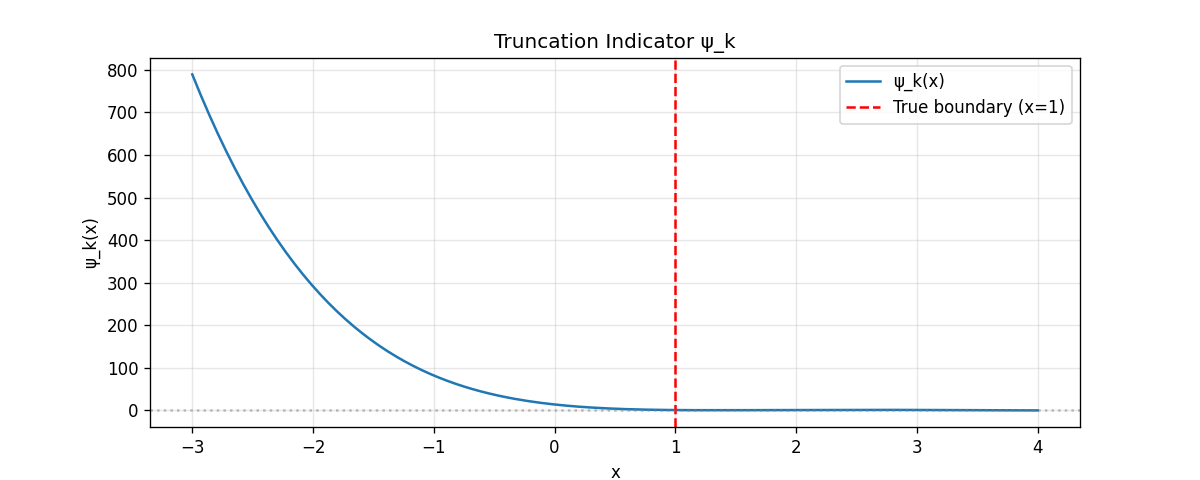

tensor(False)

In [706]:
def test_psi_k_on_data():
    """Test that psi_k correctly identifies the truncation set"""
    
    # Generate test points inside and outside truncation set
    test_inside = ch.linspace(-1, 0.99, 100).reshape(-1, 1)  # x < 1
    test_outside = ch.linspace(1.01, 4, 100).reshape(-1, 1)  # x >= 1
    
    psi_inside = unknown_gaussian_oracle.psi_k(test_inside)
    psi_outside = unknown_gaussian_oracle.psi_k(test_outside)
    
    print("\nψ_k diagnostics:")
    print(f"ψ_k on training samples: {unknown_gaussian_oracle.psi_k(S).mean():.4f} (should be ~1)")
    print(f"ψ_k inside S (x<1): {psi_inside.mean():.4f} (should be ~1)")
    print(f"ψ_k outside S (x>=1): {psi_outside.mean():.4f} (should be ~0)")
    
    # Visualize
    import matplotlib.pyplot as plt
    
    test_range = ch.linspace(-3, 4, 200).reshape(-1, 1)
    psi_vals = unknown_gaussian_oracle.psi_k(test_range).detach().squeeze()
    
    plt.figure(figsize=(10, 4))
    plt.plot(test_range.squeeze(), psi_vals, label='ψ_k(x)')
    plt.axvline(x=1, color='r', linestyle='--', label='True boundary (x=1)')
    plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    plt.xlabel('x')
    plt.ylabel('ψ_k(x)')
    plt.title('Truncation Indicator ψ_k')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return psi_inside.mean() > 0.7 and psi_outside.mean() < 0.3

test_psi_k_on_data()

In [643]:
def test_exp_h():
    """Test that exp_h is computing the density ratio correctly"""
    
    # exp_h should compute: exp[h(u,B;x)] = N(u,B;x) / N(0,I;x)
    # which is the ratio of two Gaussian densities
    
    exp_h = Exp_h(emp_loc, ch.eye(1))
    
    test_points = ch.linspace(-3, 3, 100).reshape(-1, 1)
    
    std_norm_pts = test_points
    
    emp_dist = MultivariateNormal(emp_loc, ch.eye(D))
    dist_std = MultivariateNormal(ch.zeros(1), ch.eye(1))
    
    for mu_test in [0.0, 0.5, 1.0, 1.5]:
        mu_tensor = ch.tensor([mu_test])
        
        # Compute exp_h
        exp_h_vals = exp_h(mu_tensor, ch.eye(1, 1), std_norm_pts)
        
        # Compute expected ratio manually
        dist_candidate = MultivariateNormal(mu_tensor, ch.eye(1))
        
        expected_ratio = ch.exp(dist_std.log_prob(std_norm_pts - emp_loc) - 
                                 dist_candidate.log_prob(std_norm_pts - emp_loc))
        
        error = (exp_h_vals.squeeze() - expected_ratio).abs().max()
        print(f"μ={mu_test}: max error in exp_h = {error:.6f}")
        
        if error > 0.01:
            print(f"  WARNING: exp_h may be incorrect!")
            import ipdb; ipdb.set_trace()

# test_exp_h()

In [707]:
def test_hermite_orthogonality():
    """
    Test that Hermite basis functions of different degrees are orthogonal.
    For normalized Hermite: E[H_i(x)^2] = 1, E[H_i(x)H_j(x)] = 0 if i≠j
    """
    k = 5  # max degree to test
    n_samples = 1000000
    
    # Generate samples from standard normal
#     ch.manual_seed(1000)
    samples = ch.randn(n_samples, 1)
    
    # Create ONE oracle with all degrees up to k
    oracle = UnknownGaussian(k, samples)
    
    # Get all Hermite basis function values
    H_vals = oracle.H_v(samples)  # shape: (n_samples, k+1) for 1D
    
    print(f"Testing orthogonality for degrees 0 to {k}")
    print(f"Number of basis functions: {H_vals.shape[1]}")
    print("=" * 70)
    
    # Test orthogonality
    failed = False
    for i in range(k+1):
        for j in range(k+1):
            # Since oracle includes all degrees 0..k, and in 1D each degree
            # corresponds to one basis function at index i
            Hi = H_vals[:, i]  # degree i basis function
            Hj = H_vals[:, j]  # degree j basis function
            
            # Compute E[H_i(x) * H_j(x)]
            inner_product = (Hi * Hj).mean().item()
            
            if i == j:
                # Should be 1.0 because you normalized by sqrt(factorial)
                expected = 1.0
                error = abs(inner_product - expected)
                status = "✓" if error < 0.05 else "✗"
                print(f"{status} E[H_{i}²] = {inner_product:.6f}, expected {expected:.6f}")
                if error >= 0.05:
                    failed = True
            else:
                # Should be 0
                expected = 0.0
                error = abs(inner_product)
                if error > 0.05:
                    status = "✗"
                    print(f"{status} E[H_{i} · H_{j}] = {inner_product:.6f}, expected {expected:.6f}")
                    failed = True
    
    print("=" * 70)
    if not failed:
        print("✓ ALL TESTS PASSED")
    else:
        print("✗ SOME TESTS FAILED")
    
    return not failed

# test_hermite_orthogonality()

# Vary MU and Observe Loss Function Convexity 

In [870]:
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
print(f'emp loc: {emp_loc.tolist()}')
print(f'emp var: {emp_var.tolist()}')

std_S = (S - emp_loc) / ch.sqrt(emp_var)
# std_S = S - emp_loc
std_normal = MultivariateNormal(ch.zeros(D), ch.eye(D))
std_loc_S, std_var_S = std_S.mean(0), std_S.var(0, keepdim=True)


pdf = ch.exp(std_normal.log_prob(std_S))[...,None]
v_grad =  std_loc_S - std_S
B_grad = .5 * (ch.bmm(std_S.unsqueeze(2), std_S.unsqueeze(1)) - std_var_S - std_loc_S[...,None] @ std_loc_S[None,...]).flatten(1)
data = ch.cat([std_S, pdf, v_grad, B_grad], dim=1)

k = 12
unknown_gaussian_oracle = UnknownGaussian(k, std_S)
exp_h = Exp_h(std_loc_S, std_var_S)

print("=== DATA INFO ===")
print("empirical mean (original):", emp_loc.tolist())
print("empirical variance (original):", emp_var.tolist())
print("std_S mean:", std_S.mean(0).tolist())
print("std_S min/max:", std_S.min(0), std_S.max(0))
print("first 5 points:", std_S[:5].tolist())

emp loc: [0.7956080638090791]
emp var: [[0.36204440866680504]]
=== DATA INFO ===
empirical mean (original): [0.7956080638090791]
empirical variance (original): [[0.36204440866680504]]
std_S mean: [-6.252776074688882e-17]
std_S min/max: torch.return_types.min(
values=tensor([-1.3222]),
indices=tensor([8554])) torch.return_types.max(
values=tensor([6.0771]),
indices=tensor([5242]))
first 5 points: [[-0.13303899067213867], [-0.10869739529512648], [0.04063606986773134], [-1.0766656440963687], [-1.2643267195406418]]


In [714]:
mus = ch.linspace(-3.0, 3.25, 25) 

losses, mu_grads = ch.Tensor([]), ch.Tensor([])
weighted_means = []

for mu in mus: 
    loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu[...,None], ch.eye(1, 1) / emp_var, data)
    
    print(f"mu = {mu.item():.3f}")
    print("  loss:", loss.item())
    print("  loc_grad mean:", loc_grad.mean().item())
    print("  loc_grad min/max:", loc_grad.min().item(), loc_grad.max().item())
    print("  cov_grad mean:", cov_grad.mean().item())

    weights = exp_h(mu[...,None], ch.eye(1, 1), std_S)
    weighted_mean = (weights * std_S).mean()
    print(f"mu={mu:.2f}, weighted mean={weighted_mean.item()}")
    weighted_means.append(weighted_mean)

    losses = ch.cat([losses, loss])
    mu_grads = ch.cat([mu_grads, loc_grad])
    
losses = losses.detach()

mu = -3.000
  loss: 2.467618825952975
  loc_grad mean: -1.8499132563675782
  loc_grad min/max: -1.8499132563675782 -1.8499132563675782
  cov_grad mean: -0.27504025394053083
mu=-3.00, weighted mean=37.79729810489352
mu = -2.740
  loss: 2.2950584439431463
  loc_grad mean: -1.6702458778304043
  loc_grad min/max: -1.6702458778304043 -1.6702458778304043
  cov_grad mean: -0.2735376914533677
mu=-2.74, weighted mean=28.179756259626885
mu = -2.479
  loss: 2.1393413628181865
  loc_grad mean: -1.5062808078399115
  loc_grad min/max: -1.5062808078399115 -1.5062808078399115
  cov_grad mean: -0.2710742096783265
mu=-2.48, weighted mean=20.975628568903808
mu = -2.219
  loss: 1.999014657279001
  loc_grad mean: -1.3562542743032677
  loc_grad min/max: -1.3562542743032677 -1.3562542743032677
  cov_grad mean: -0.2676915362530902
mu=-2.22, weighted mean=15.33170897224255
mu = -1.958
  loss: 1.8727914676630133
  loc_grad mean: -1.2185409630634991
  loc_grad min/max: -1.2185409630634991 -1.2185409630634991
  c

<IPython.core.display.Javascript object>


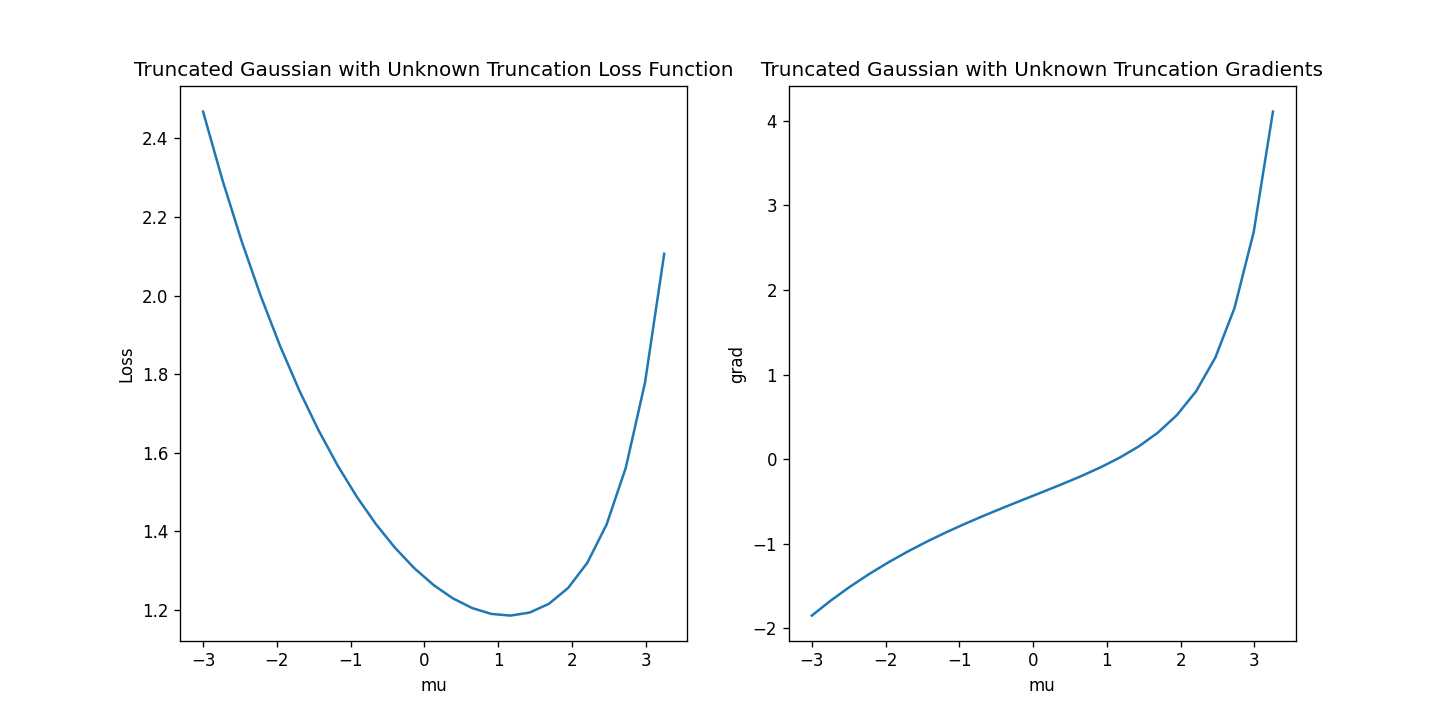

In [715]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(mus, losses)
ax1.set_title('Truncated Gaussian with Unknown Truncation Loss Function')
ax1.set_xlabel('mu')
ax1.set_ylabel('Loss')

ax2.set_title('Truncated Gaussian with Unknown Truncation Gradients')
ax2.plot(mus, mu_grads)
ax2.set_xlabel('mu')
ax2.set_ylabel('grad')

plt.show()

In [716]:
mus[losses.argmin()] * ch.sqrt(emp_var) + emp_loc

tensor([[2.9091]])

In [717]:
mus[mu_grads.abs().argmin()] * ch.sqrt(emp_var) + emp_loc

tensor([[2.9091]])

# Vary Sigma and Observe Loss Function Convexity

In [718]:
sigmas = ch.linspace(2.0, 5.0, 100) 

losses, cov_grads = ch.Tensor([]), ch.Tensor([])

for sigma in sigmas: 
    var_ = ch.Tensor([[sigma]])
    loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ((3 - emp_loc) / ch.sqrt(emp_var)).flatten(), var_, data)
    losses = ch.cat([losses, loss])
    cov_grads = ch.cat([cov_grads, cov_grad])
    
losses = losses.detach()

<IPython.core.display.Javascript object>


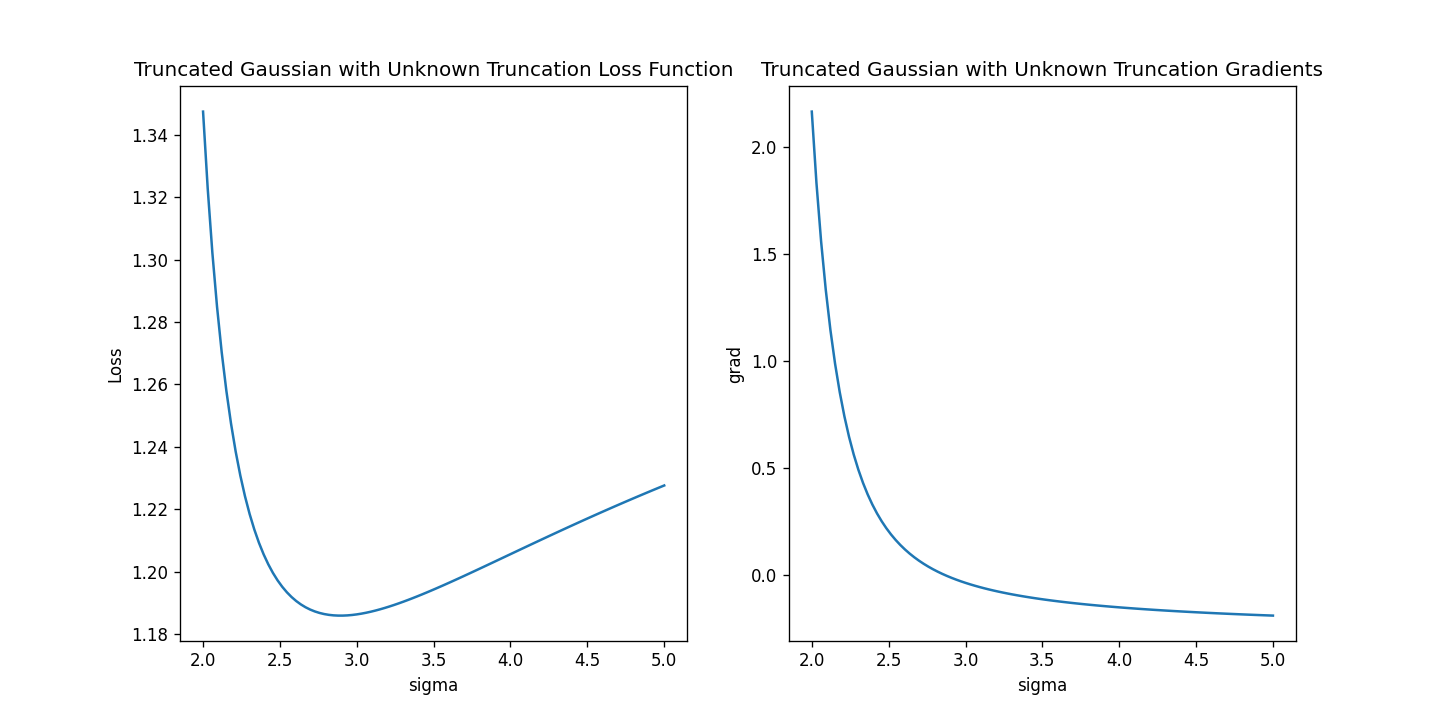

In [719]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(sigmas, losses)
ax1.set_title('Truncated Gaussian with Unknown Truncation Loss Function')
ax1.set_xlabel('sigma')
ax1.set_ylabel('Loss')
ax2.set_title('Truncated Gaussian with Unknown Truncation Gradients')
ax2.plot(sigmas, cov_grads)
ax2.set_xlabel('sigma')
ax2.set_ylabel('grad')

plt.show()

In [720]:
sigmas[losses.argmin()].resize(1, 1) * emp_var

tensor([[1.0961]])

In [721]:
sigmas[cov_grads.abs().argmin()] * emp_var

tensor([[1.0847]])

In [814]:
unknown_gaussian_oracle.dist = MultivariateNormal((3*ch.eye(1) - emp_loc) / ch.sqrt(emp_var), ch.eye(1, 1) / emp_var)

grid = ch.linspace(-2, 4, 1001).view(-1,1)
std_grid = (grid - emp_loc) / ch.sqrt(emp_var)
psi_grid = unknown_gaussian_oracle(std_grid).squeeze().detach().cpu().numpy() 
# find first grid point where psi>0.5

In [815]:
grid[(psi_grid == 0).argmax()], S.min()

(tensor([-0.6260]), tensor(-1.5610))

<IPython.core.display.Javascript object>


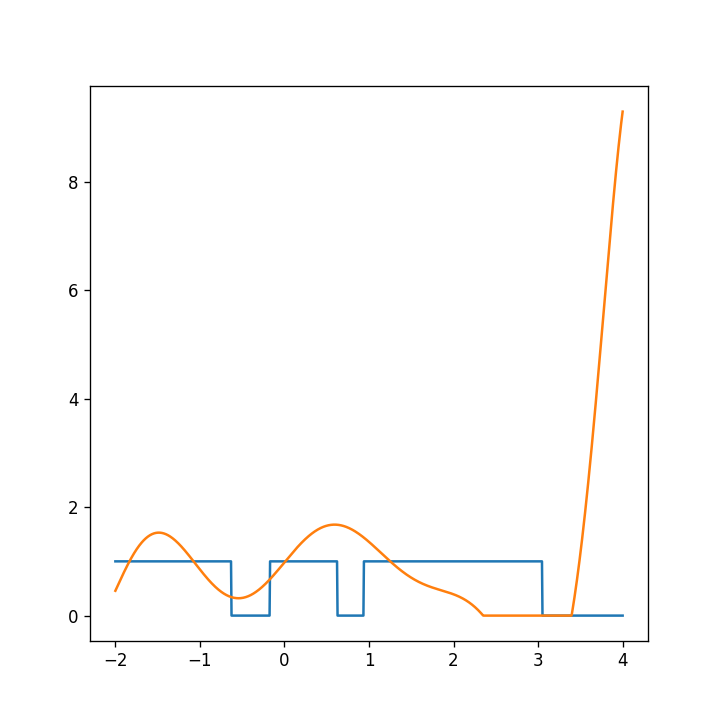

In [816]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.plot(grid , psi_grid)
ax.plot(grid, unknown_gaussian_oracle.psi_k(grid))
plt.show()

In [967]:
D = 1
num_samples = 20000
true_mu = ch.zeros(D)
true_var = ch.eye(D)
M = MultivariateNormal(true_mu, true_var)

def phi(x): return x > 0

S, alpha, X = generate_data(phi, num_samples, M, D, verbose=True)

alpha: 0.499


In [968]:
k = 30
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
print(f'emp loc: {emp_loc.tolist()}')
print(f'emp var: {emp_var.tolist()}')

std_S = (S - emp_loc) / ch.sqrt(emp_var)
std_loc_S, std_var_S = std_S.mean(0), std_S.var(0)
unknown_gaussian_oracle = UnknownGaussian(k, std_S)
exp_h = Exp_h(std_S_loc, std_S_var)

pdf = ch.exp(std_normal.log_prob(std_S))[...,None]
loc_grad =  std_loc_S - std_S
cov_grad = .5 * (ch.bmm(std_S.unsqueeze(2), std_S.unsqueeze(1)) - std_var_S - std_loc_S[...,None] @ std_loc_S[None,...]).flatten(1)
data = ch.cat([std_S, pdf, loc_grad, cov_grad], dim=1) 
print("=== DATA INFO ===")
print("empirical mean (original):", emp_loc.tolist())
print("empirical variance (original):", emp_var.tolist())
print("std_S mean:", std_loc_S.tolist())
print("std_S variance:", std_var_S.tolist())
print("std_S min/max:", std_S.min(0), std_S.max(0))
print("first 5 points:", std_S[:5].tolist())

emp loc: [0.7932742596253515]
emp var: [[0.3703717453862534]]
=== DATA INFO ===
empirical mean (original): [0.7932742596253515]
empirical variance (original): [[0.3703717453862534]]
std_S mean: [-3.765876499528531e-17]
std_S variance: [0.9999999999999991]
std_S min/max: torch.return_types.min(
values=tensor([-1.3034]),
indices=tensor([12206])) torch.return_types.max(
values=tensor([5.2490]),
indices=tensor([14537]))
first 5 points: [[0.02974885956526737], [0.26589596867084125], [1.5551784729872309], [-1.0468321459160237], [-0.5005620152736855]]


In [969]:
v_values = ch.linspace(-2.0, 2.0, 30)
t_values = ch.linspace(0.1, 1.5, 30)
V, T = ch.meshgrid(v_values, t_values)

Z = np.zeros_like(MU)
V_GRAD = np.zeros_like(V)
T_GRAD = ch.zeros_like(T) 
for i in range(len(t_values)):
    for j in range(len(v_values)):
        t = ch.Tensor([[T[i, j]]])
        loss, t_grad, v_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, V[i, j][...,None], t, data)
        Z[i, j] = loss
        V_GRAD[i, j] = v_grad.flatten()
        T_GRAD[i, j] = t_grad.flatten()

In [970]:
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_v = V[min_idx]
min_T = T[min_idx]
min_loss = Z[min_idx]
true_mu_std = ((true_mu - emp_loc) / ch.sqrt(emp_var)).flatten()
true_var_std = true_var / emp_var
true_T = true_var_std.inverse()
true_v = true_T@true_mu_std
print(f"Ground truth: v={true_v.item():.3f}, T={true_T.item():.3f}")
print(f"Minimum found: v={min_v:.3f}, T={min_T:.3f}, loss={min_loss:.3f}")
gt_loss = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, true_v, true_T, data)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

Ground truth: v=-0.483, T=0.370
Minimum found: v=-0.483, T=0.341, loss=1.186

Loss at ground truth: 1.186
Loss at minimum: 1.186
Difference: -0.000


<IPython.core.display.Javascript object>


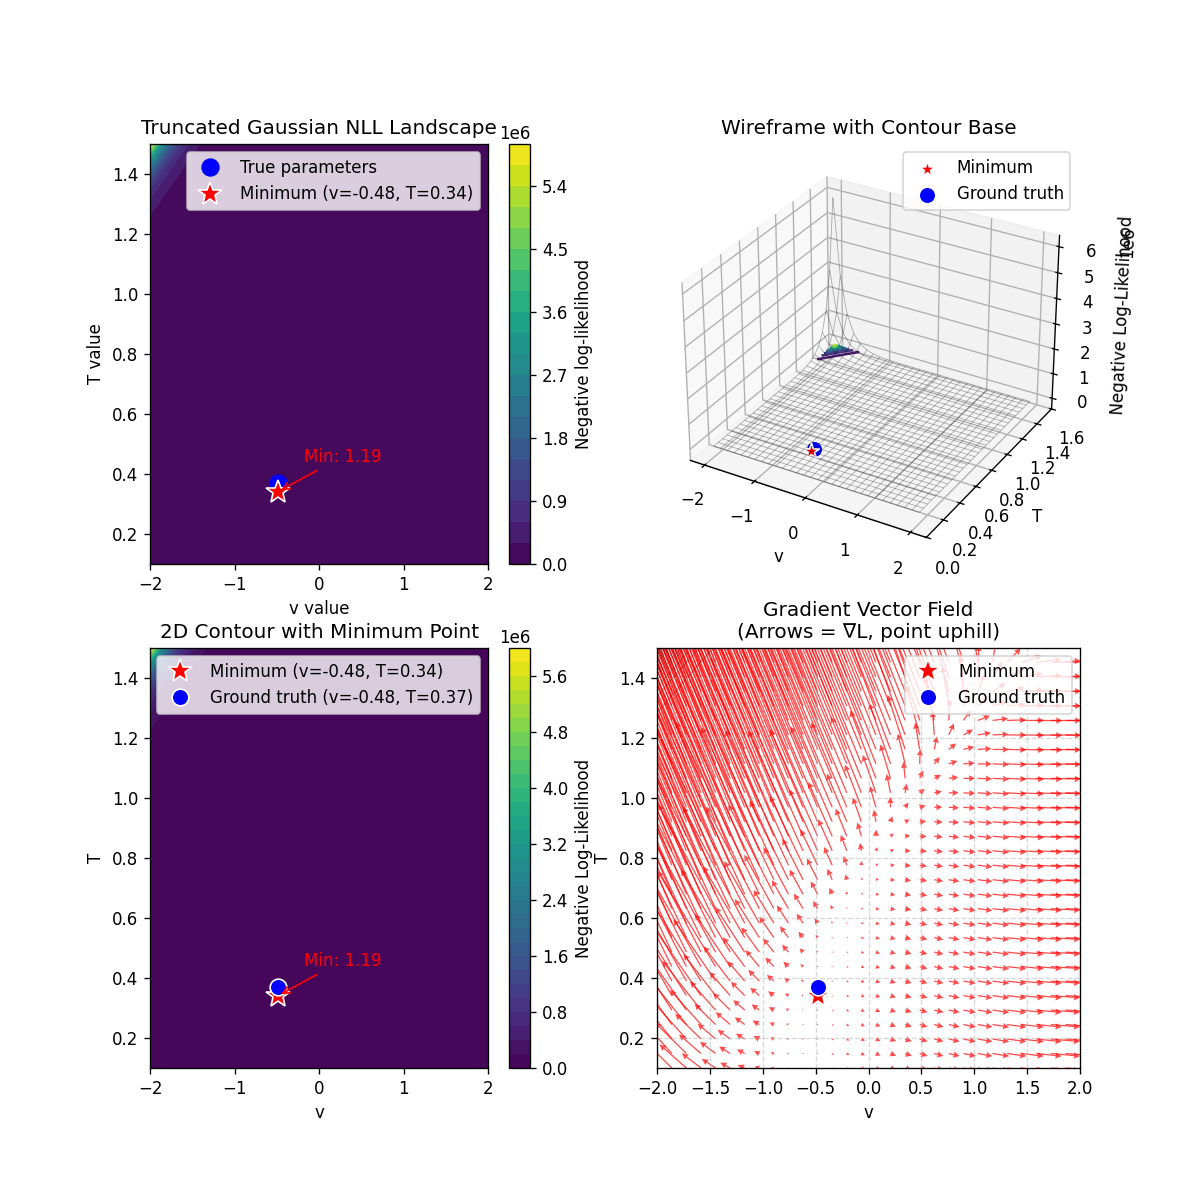

In [971]:
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221,)
cp = ax1.contourf(V, T, Z, levels=20, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Gaussian NLL Landscape")
ax1.set_xlabel("v value")
ax1.set_ylabel("T value")

# mark the ground truth
ax1.plot(true_v.item(), true_T.item(), 'bo', markersize=10, label="True parameters")

ax1.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (v={min_v:.2f}, T={min_T:.2f})')

ax1.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_v, min_T), 
            xytext=(min_v+0.3, min_T+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_wireframe(V, T, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(V, T, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_v], [min_T], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_v.item()], [true_T.item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('v')
ax2.set_ylabel('T')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(223)
contourf = ax3.contourf(V, T, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (v={min_v:.2f}, T={min_T:.2f})')
ax3.plot(true_v.item(), true_T.item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (v={true_v.item():.2f}, T={true_T.item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_v, min_T), 
            xytext=(min_v+0.3, min_T+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.set_xlabel('v')
ax3.set_ylabel('T')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(224)

# Plot quiver
Q = ax4.quiver(V, T, V_GRAD, T_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(V, T, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(min_v, min_T, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(true_v.item(), true_T.item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax4.set_xlabel('v')
ax4.set_ylabel('T')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [972]:
min_var_std = min_T.resize(1, 1).inverse()
min_mu_std = min_var_std * min_v

In [973]:
min_var_std*emp_var

tensor([[1.0849]])

In [974]:
min_mu = min_mu_std*ch.sqrt(emp_var) + emp_loc
min_mu

tensor([[-0.0673]])

In [975]:
(true_T.inverse()*true_v) * ch.sqrt(emp_var) + emp_loc

tensor([[0.]], grad_fn=<AddBackward0>)

In [977]:
true_T.inverse()*emp_var

tensor([[1.]], grad_fn=<MulBackward0>)

In [ ]:
unknown_gaussian_oracle.dist = MultivariateNormal((ch.eye(1) - emp_loc) / ch.sqrt(emp_var), ch.eye(1, 1) / emp_var)

grid = ch.linspace(-2, 4, 1001).view(-1,1)
std_grid = (grid - emp_loc) / ch.sqrt(emp_var)
psi_grid = unknown_gaussian_oracle(std_grid).squeeze().detach().cpu().numpy() 
# find first grid point where psi>0.5

# Two Dimensional Gaussian

In [106]:
# === Ground truth parameters ===
D = 2
true_mu = ch.zeros(D)
true_var = ch.eye(D)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [0.0, 0.0]
true covariance: [[1.0, 0.0], [0.0, 1.0]]


alpha: 0.247


<IPython.core.display.Javascript object>


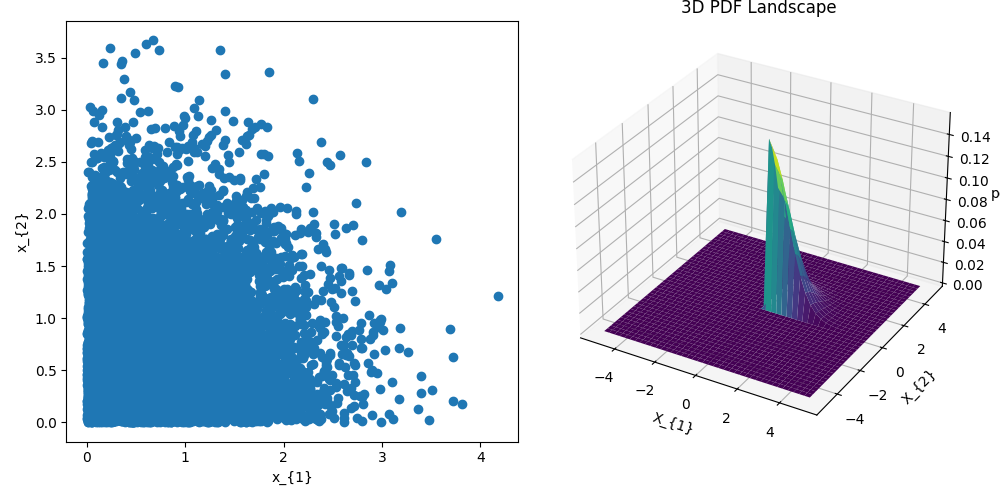

In [107]:
M = MultivariateNormal(ch.zeros(D), ch.eye(D))
SAMPLES = M.sample([1000])

# === Synthetic truncated dataset ===
M = MultivariateNormal(true_mu, true_var)

# === Truncation region ===
def phi(z):
    # Keep only samples where both coordinates > 0
    return (z > 0).prod(dim=-1, keepdim=True)
S, alpha, samples = generate_data(phi, num_samples, M, D, verbose=True)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.scatter(S[:,0], S[:,1])
ax1.set_xlabel('x_{1}')
ax1.set_ylabel('x_{2}')

x_ = ch.linspace(-5.0, 5.0, 40)
y_ = ch.linspace(-5.0, 5.0, 40)
X, Y = ch.meshgrid(x_, y_)

coords = ch.stack([X, Y], dim=-1)
coords_flat = coords.reshape(-1, 2)

pdfs = ch.exp(M.log_prob(coords_flat))[...,None]
mask = phi(coords_flat)

truncated_pdfs = (pdfs * mask).reshape(X.shape)   
        
ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(X, Y, truncated_pdfs,cmap='viridis',linewidth=0)
ax2.set_xlabel('X_{1}')
ax2.set_ylabel('X_{2}')
ax2.set_zlabel('pdf')
ax2.set_title('3D PDF Landscape')

plt.tight_layout()
plt.show()

In [108]:
k = 5
emp_loc, cov_ = S.mean(0), ch.eye(D)
unknown_gaussian_oracle = UnknownGaussian(emp_loc, cov_, S, k)

pdf = ch.exp(M.log_prob(S))[...,None]
loc_grad =  emp_loc - S
cov_grad = .5 * (ch.bmm(S.unsqueeze(2), S.unsqueeze(1)) - emp_var - emp_loc[...,None] @ emp_loc[None,...]).flatten(1)
data = ch.cat([S, pdf, loc_grad, cov_grad], dim=1) 

<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:21: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_233477/3405096069.py:21: SyntaxWarning: invalid escape sequence '\i'
  ax2.set_zlabel('x \in S')


<IPython.core.display.Javascript object>


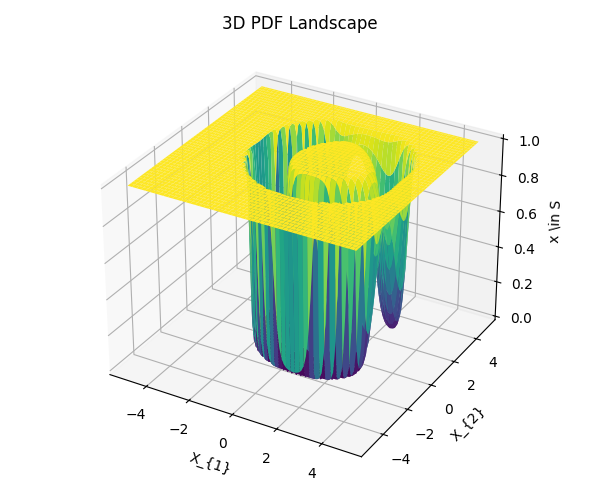

In [109]:
x_, y_ = ch.linspace(-5, 5, 100), ch.linspace(-5, 5, 100)
x_mesh, y_mesh = ch.meshgrid(x_, y_)

psi_ = ch.zeros_like(x_mesh)
for i in range(len(x_mesh)): 
    for j in range(len(y_mesh)): 
        s = ch.cat([x_mesh[i, j][...,None], y_mesh[i, j][...,None]])[None,...]
        psi_k = unknown_gaussian_oracle.psi_k(s)
        psi_[i, j] = psi_k
        


fig = plt.figure(figsize=(6, 5))


ax2 = fig.add_subplot(111, projection='3d')

ax2.plot_surface(x_mesh, y_mesh, psi_, cmap='viridis',linewidth=0)
ax2.set_xlabel('X_{1}')
ax2.set_ylabel('X_{2}')
ax2.set_zlabel('x \in S')
ax2.set_title('3D PDF Landscape')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


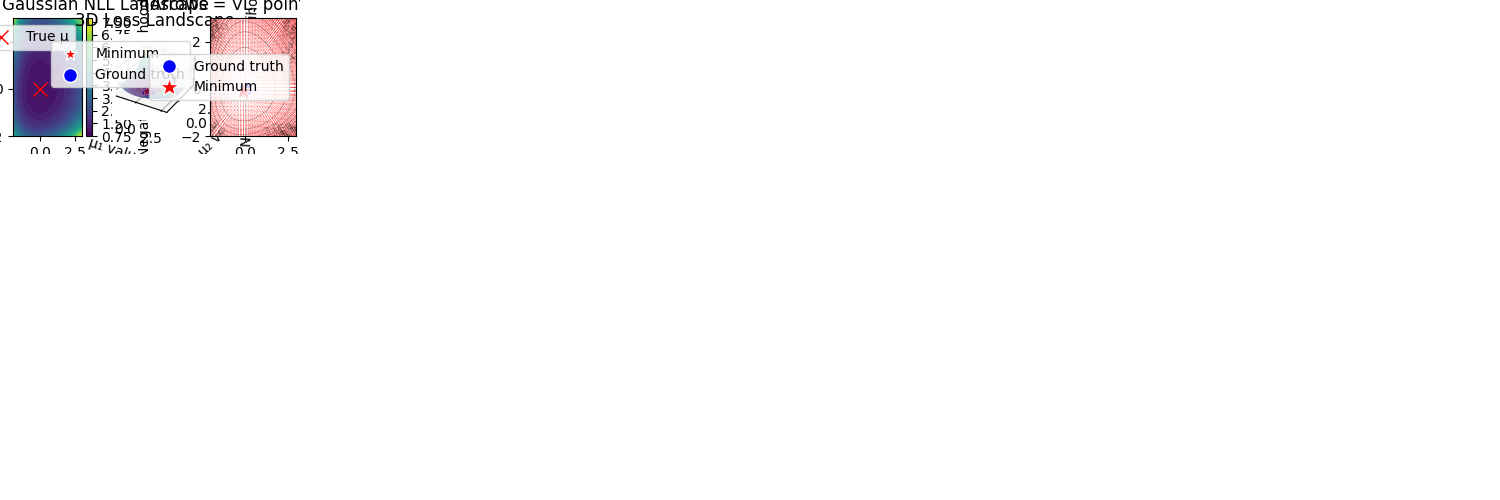


Loss at ground truth: 0.993
Loss at minimum: 0.994
Difference: -0.001


In [110]:
exp_h = Exp_h(emp_loc, ch.eye(D))

# === Parameter grid for μ₁ and μ₂ ===
mu1_vals = ch.linspace(-2.0, 3.0, 40)
mu2_vals = ch.linspace(-2.0, 3.0, 40)
MU1, MU2 = ch.meshgrid(mu1_vals, mu2_vals)

Z = np.zeros_like(MU1)
MU1_GRAD = ch.zeros_like(MU1)
MU2_GRAD = ch.zeros_like(MU2)
for i in range(len(mu2_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.Tensor([MU1[i, j], MU2[i, j]])
        loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu_vec, cov_, data, dims=D)
        Z[i, j] = loss
        MU1_GRAD[i, j] = loc_grad[0]
        MU2_GRAD[i, j] = loc_grad[1]
        
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu_1, min_mu_2 = MU1[min_idx], MU2[min_idx]
min_loss = Z[min_idx]

fig = plt.figure(figsize=(15, 5))

# === 2D contour plot ===
ax1 = fig.add_subplot(131)
cp = ax1.contourf(MU1, MU2, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("2D Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ₁ value")
ax1.set_ylabel("μ₂ value")

# mark the ground truth
ax1.plot(true_mu[0].item(), true_mu[1].item(), 'rx', markersize=10, label="True μ")
ax1.legend()

# === 3D surface plot ===
ax2 = fig.add_subplot(132, projection='3d')
surf = ax2.plot_surface(MU1, MU2, Z, cmap='viridis', alpha=0.85,
                        linewidth=0, antialiased=True)

# plot key points
ax2.scatter([min_mu_1], [min_mu_2], [min_loss],
            color='red', s=100, label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu[0].item()], [true_mu[1].item()], [np.min(Z)],
            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')

# formatting
ax2.set_xlabel('μ₁ value')
ax2.set_ylabel('μ₂ value')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('3D Loss Landscape')
ax2.legend()

# fix clipping
ax2.set_box_aspect((1, 1, 0.6))  # prevents z from being squashed
ax2.set_xlim(MU1.min(), MU1.max())
ax2.set_ylim(MU2.min(), MU2.max())
ax2.set_zlim(Z.min() - 0.1 * abs(Z.min()), Z.max() + 0.1 * abs(Z.max()))

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, MU2, MU1_GRAD, MU2_GRAD,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, MU2, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(true_mu[0].item(), true_mu[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax3.plot(min_mu_1, min_mu_2, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('μ_2')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
loss = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ch.zeros(D,), cov_, data, dims=D)[0].item()
print(f"\nLoss at ground truth: {loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {loss - min_loss:.3f}")

# Vary mu_1 and sigma_1

/tmp/ipykernel_233477/3720593500.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)


<IPython.core.display.Javascript object>


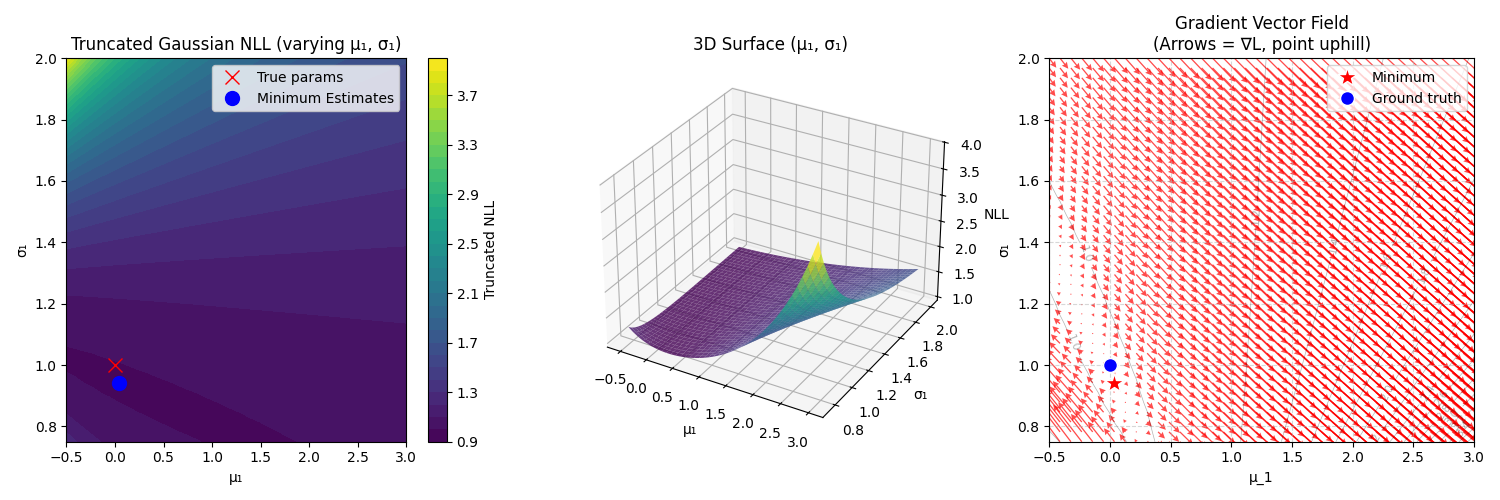


Loss at ground truth: 0.993
Loss at minimum: 0.993
Difference: 0.000


In [37]:
from delphi.utils.helpers import cov
cov_ = cov(S)
exp_h = Exp_h(emp_loc, cov_)


# ==== Vary μ₁ and σ₁ (fix μ₂, σ₂) ====
mu1_vals = ch.linspace(-.5, 3, 40)
sigma1_vals = ch.linspace(0.75, 2.0, 40)
MU1, SIGMA1 = ch.meshgrid(mu1_vals, sigma1_vals)
Z_mu_sigma = ch.zeros_like(MU1)
GRAD_MU1 = ch.zeros_like(MU1)
GRAD_SIGMA1 = ch.zeros_like(SIGMA1)

sigma2_fixed = 1.0

for i in range(len(sigma1_vals)):
    for j in range(len(mu1_vals)):
        mu = ch.tensor([MU1[i, j], true_mu[1]])
        
        Sigma = ch.diag(ch.tensor([SIGMA1[i, j], sigma2_fixed]))
        loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu, Sigma, data, dims=D)

        Z_mu_sigma[i, j] = loss
        GRAD_MU1[i, j] = loc_grad[0]
        GRAD_SIGMA1[i, j] = cov_grad[0, 0]
        
Z_mu_sigma = Z_mu_sigma.detach()
min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)
min_mu_1, min_sigma_1 = MU1[min_idx], SIGMA1[min_idx]
min_loss = Z_mu_sigma[min_idx]

# ==== Visualization ====
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1)
cp = ax1.contourf(mu1_vals, sigma1_vals, Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Truncated NLL")
ax1.plot(true_mu[0], 1.0, "rx", markersize=10, label="True params")
ax1.plot(min_mu_1, min_sigma_1, "bo", markersize=10, label="Minimum Estimates")

ax1.set_title("Truncated Gaussian NLL (varying μ₁, σ₁)")
ax1.set_xlabel("μ₁")
ax1.set_ylabel("σ₁")
ax1.legend()

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(MU1, SIGMA1, Z_mu_sigma, cmap="viridis", alpha=0.8, linewidth=0)
ax2.set_xlabel("μ₁")
ax2.set_ylabel("σ₁")
ax2.set_zlabel("NLL")
ax2.set_title("3D Surface (μ₁, σ₁)")

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, SIGMA1, GRAD_MU1, GRAD_SIGMA1,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, SIGMA1, Z_mu_sigma, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(min_mu_1, min_sigma_1, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax3.plot(true_mu[0].item(), 1.0, 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('σ₁')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
loss = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, true_mu, ch.eye(D), data, dims=D)[0].item()
print(f"\nLoss at ground truth: {loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {loss - min_loss:.3f}")

In [39]:
min_sigma_1, min_mu_1

(tensor(0.9423), tensor(0.0385))

# 10 Dimensional Gaussians

In [44]:
D = 10
true_mu = ch.randn(D) 
true_Sigma = 10.0 * ch.eye(D)
dist = MultivariateNormal(true_mu, true_Sigma)

print(f'true mu: {true_mu.tolist()}')
print(f'true Sigma: {true_Sigma.tolist()}')

true mu: [1.2893456795458005, 1.0122873513999349, -0.043579447656541585, 1.0751504662949576, 1.0823997970179047, 0.4196386799946605, -0.5557916198532369, -0.4319157954769031, -1.799735173810274, 0.32434229517987195]
true Sigma: [[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0]]


# Random Matrix Projection

alpha: 0.998
Effective 2D radius (min): 0.10


<IPython.core.display.Javascript object>


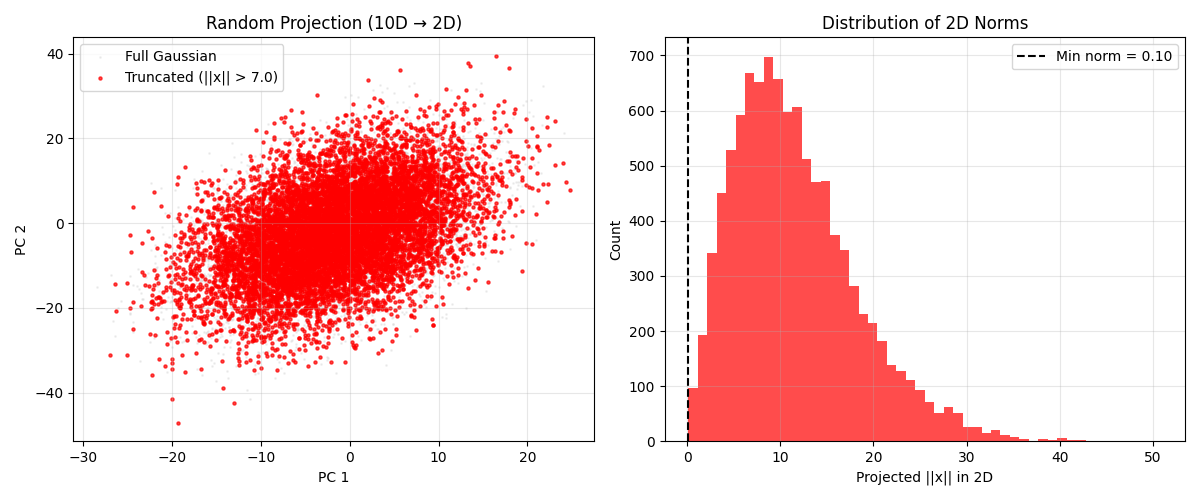

In [53]:
M = MultivariateNormal(true_mu, true_Sigma)
# === Truncation region ===
def phi(z):
    # Keep only samples, where norm of the sample is larger than 4.5
    return z.norm(dim=1, keepdim=True) > 4.5

S, alpha, samples = generate_data(phi, num_samples, M, D, verbose=True)

# Project with a random matrix
W = ch.randn(10, 2)
S_2d = S @ W
samples_full_2d = samples @ W

projected_norms = np.linalg.norm(S_2d, axis=1)
R_eff = projected_norms.min()  # or use percentile
print(f"Effective 2D radius (min): {R_eff:.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Full vs truncated in 2D PCA space
ax1.scatter(samples_full_2d[:, 0], samples_full_2d[:, 1], 
           s=1, alpha=0.3, label='Full Gaussian', color='lightgray')
ax1.scatter(S_2d[:, 0], S_2d[:, 1], 
           s=5, alpha=0.7, label='Truncated (||x|| > 7.0)', color='red')
ax1.set_title('Random Projection (10D → 2D)')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of projected norms
ax2.hist(projected_norms, bins=50, color='red', alpha=0.7)
ax2.axvline(R_eff, color='black', linestyle='--', label=f'Min norm = {R_eff:.2f}')
ax2.set_xlabel('Projected ||x|| in 2D')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of 2D Norms')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Marginzalized Projection 

<IPython.core.display.Javascript object>


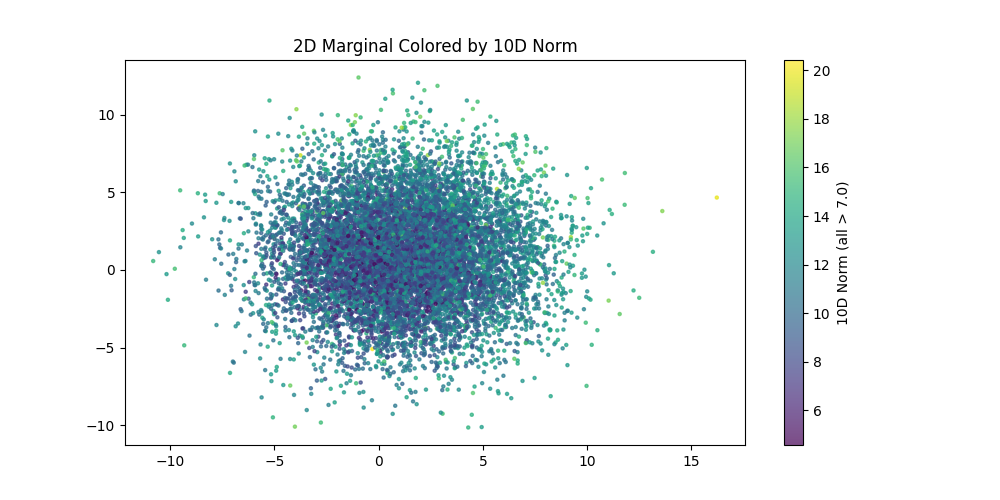

In [54]:
x_marg = S[:, :2].cpu()
norms_10d = S.norm(dim=1).cpu()

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
fig1 = ax1.scatter(x_marg[:, 0], x_marg[:, 1], c=norms_10d, s=5, alpha=0.7)
plt.colorbar(fig1, ax=ax1, label='10D Norm (all > 7.0)')
ax1.set_title('2D Marginal Colored by 10D Norm')
plt.show()

In [4]:
from delphi import oracle

dims = 1

true_mu, true_var = ch.zeros(dims), ch.eye(dims)
M = MultivariateNormal(true_mu, true_var) 
print(f'ground truth loc: {true_mu}')
print(f'ground truth var: {true_var}')
samples = M.rsample([5000,])
print(f'num total samples: {samples.size(0)}')
# generate ground-truth data
phi = oracle.Right_Distribution(ch.Tensor([0.0]))
# truncate
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
print(f'num truncated samples: {S.size(0)}')
alpha = S.size(0) / samples.size(0)
emp_loc = S.mean(0)
emp_var = S.var(0)
print(f"emp loc: {emp_loc}")
print(f'emp var: {emp_var}')

ground truth loc: tensor([0.])
ground truth var: tensor([[1.]])
num total samples: 5000
num truncated samples: 2457
emp loc: tensor([-0.8046])
emp var: tensor([0.3707])


In [5]:
from delphi.distributions import UnknownTruncationNormal
from delphi.utils.helpers import Parameters

S_std_norm = (S - emp_loc) 
k = 3

# train algorithm
args = Parameters({
                    'epochs': 20, 
                    'batch_size': 10, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
                    'early_stopping': True,
                }) 
truncated = UnknownTruncationNormal(args,
                                    k,
                                    alpha,
                                    dims,
                                    covariance_matrix=ch.eye(1))
truncated.fit(S)

rescale_loc = truncated.best_loc_
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_covariance_matrix_
print(f"pred var: {rescale_var}")

args: {'amsgrad': False,
 'batch_size': 10,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'covariance_matrix_lr': 0.01,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'early_stopping': True,
 'epochs': 20,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'step_lr': 100,
 'step_lr_gamma': 0.9,
 'tol': 0.1,
 'train_mode': 'step',
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.

ipdb> batch[1][:,0][...,None]
tensor([[-0.1745],
        [-0.1684],
        [-2.6244],
        [-1.7667],
        [-1.9945],
        [-1.7777],
        [-0.2871],
        [-1.2947],
        [-1.1266],
        [-0.7194]])
ipdb> self.exp_h(self.v, self.T, batch[1][:,0][...,None])
tensor([[ 3.0232,  3.0282,  1.5466,  1.9556,  1.8375,  1.9497,  2.9315,  2.2251,
          2.3299,  2.6045],
        [ 3.0200,  3.0250,  1.5449,  1.9536,  1.8355,  1.9477,  2.9285,  2.2228,
          2.3275,  2.6018],
        [93.2105, 93.3656, 47.6835, 60.2952, 56.6526, 60.1133, 90.3843, 68.6057,
         71.8348, 80.3019],
        [14.1780, 14.2015,  7.2530,  9.1713,  8.6172,  9.1436, 13.7481, 10.4354,
         10.9266, 12.2145],
        [21.7588, 21.7950, 11.1311, 14.0751, 13.2248, 14.0327, 21.0990, 16.0151,
         16.7689, 18.7454],
        [14.4582, 14.4822,  7.3963,  9.3526,  8.7875,  9.3244, 14.0198, 10.6416,
         11.1425, 12.4559],
        [ 3.1027,  3.1079,  1.5873,  2.0071,  1.8858,  2.0010,  3.0

In [21]:
from delphi import oracle
dims = 1
# generate ground-truth data
M = MultivariateNormal(ch.zeros(dims), ch.eye(dims)) 
samples = M.rsample([10000,])
phi = oracle.Right_Distribution(ch.Tensor([0.0]))
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
alpha = S.size(0) / samples.size(0)

print(f'alpha: {alpha}')
print(f'num total samples: {samples.size(0)}')
print(f'num truncated samples: {S.size(0)}')
emp_loc = S.mean(0)
emp_var = S.var(0)

print(f'emp loc: {emp_loc}')
print(f'emp var: {emp_var}')
print(f'known variance: {M.covariance_matrix}')
k = 3
print(f'k: {k}')

S_norm = S - emp_loc

# train algorithm
args = Parameters({
                    'epochs': 2, 
                    'trials': 1,
                    'batch_size': 1000,
                    'lr': 1e-1, 
                    'early_stopping': True,
                    'verbose': True,
                    'step_lr_gamma': 1.0,
                }) 
truncated = UnknownTruncationNormal(args, 
                                    k, 
                                    alpha, 
                                    dims, 
                                    covariance_matrix=M.covariance_matrix)
truncated.fit(S)

alpha: 0.5007
num total samples: 10000
num truncated samples: 5007
emp loc: tensor([-0.7983])
emp var: tensor([0.3605])
known variance: tensor([[1.]])
k: 3
args: {'amsgrad': False,
 'batch_size': 1000,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'covariance_matrix_lr': 0.01,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'early_stopping': True,
 'epochs': 2,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'step_lr': 100,
 'step_lr_gamma': 1.0,
 'tol': 0.1,
 'train_mode': 'step',
 'trials': 1,
 'val': 0

UnknownTruncationNormal()

In [22]:
dims = 1
std_normal = MultivariateNormal(ch.zeros(dims), ch.eye(dims))
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)

pdf = ch.exp(std_normal.log_prob(S))[...,None]
loc_grad =  emp_loc - S
cov_grad = .5 * (ch.bmm(S.unsqueeze(2), S.unsqueeze(1)) - emp_var - emp_loc[...,None] @ emp_loc[None,...]).flatten(1)
data = ch.cat([S, pdf, loc_grad, cov_grad], dim=1)

k = 3
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
unknown_gaussian_oracle = UnknownGaussian(emp_loc[...,None], ch.eye(dims), S, k)
exp_h = Exp_h(emp_loc, ch.eye(dims))

In [23]:
ch.randperm(data.size(0))[:10]

tensor([1850, 3201, 4812, 2297, 1489, 4463, 4862, 2227, 3140, 3457])

In [24]:
mus = ch.linspace(-1, 2, 10)
losses = [unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ch.tensor([m])[None,...], ch.eye(1), truncated.val_loader_.dataset.data)[0].item() for m in mus]

<IPython.core.display.Javascript object>


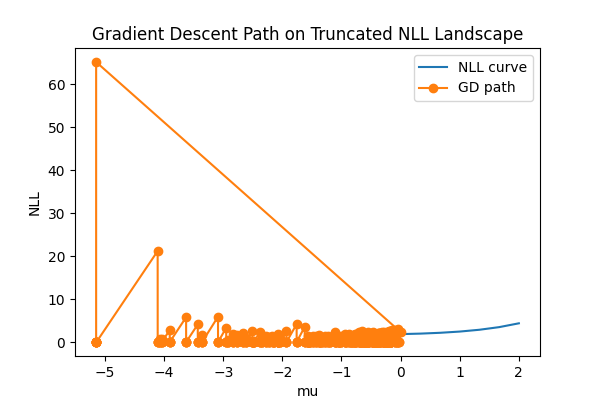

In [25]:
mu_history = truncated.trainer.param_history[:,1].detach()
loss_history = truncated.trainer.loss_history.detach()

plt.figure(figsize=(6,4))
plt.plot(mus, losses, label="NLL curve")
plt.plot(mu_history, loss_history, marker="o", label="GD path")
plt.xlabel("mu")
plt.ylabel("NLL")
plt.title("Gradient Descent Path on Truncated NLL Landscape")
plt.legend()
plt.show()

In [108]:
truncated.val_loader_.dataset.data

tensor([[-1.6164,  0.2721,  0.8059,  0.7939],
        [-0.5317,  0.5917, -0.2788, -0.3711],
        [-2.3500,  0.0263,  1.5395,  2.2487],
        ...,
        [-0.6345,  0.6305, -0.1760, -0.3112],
        [-0.1239,  0.3466, -0.6866, -0.5048],
        [-1.7603,  0.1930,  0.9498,  1.0369]])

In [26]:
truncated.trainer.param_history

tensor([[ 1.0000, -0.7950],
        [ 1.0000, -0.7948],
        [ 1.0000, -0.7947],
        [ 1.0000, -0.7946],
        [ 1.0000, -0.7484],
        [ 1.0000, -0.7483],
        [ 1.0000, -0.7481],
        [ 1.0000, -0.7480],
        [ 1.0000, -0.7479],
        [ 1.0000, -0.6490],
        [ 1.0000, -0.6488],
        [ 1.0000, -0.6487],
        [ 1.0000, -0.6486],
        [ 1.0000, -0.6484],
        [ 1.0000, -0.6268],
        [ 1.0000, -0.6266],
        [ 1.0000, -0.6264],
        [ 1.0000, -0.6263],
        [ 1.0000, -0.6262],
        [ 1.0000, -0.5974],
        [ 1.0000, -0.5974],
        [ 1.0000, -0.5972],
        [ 1.0000, -0.5971],
        [ 1.0000, -0.5969],
        [ 1.0000, -0.5876],
        [ 1.0000, -0.5875],
        [ 1.0000, -0.5873],
        [ 1.0000, -0.5872],
        [ 1.0000, -0.5871],
        [ 1.0000, -0.5456],
        [ 1.0000, -0.5455],
        [ 1.0000, -0.5454],
        [ 1.0000, -0.5452],
        [ 1.0000, -0.5450],
        [ 1.0000, -0.5393],
        [ 1.0000, -0

In [31]:
mu_history[loss_history.argmax() - 1]

tensor(0.0065)

In [68]:
S_std_norm = (S - emp_loc) / (emp_var ** .5)
phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten() / (emp_var ** .5))


# train algorithm
args = Parameters({
                    'epochs': 10, 
                    'batch_size': 50, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
#                     'step_lr_gamma': 1.0,
                    'num_samples': 10000,
#                     'optimizer': 'adam'
                }) 
truncated = TruncatedNormal(args,
                              phi_std_norm, 
                              alpha, 
                              dims)
truncated.fit(S_std_norm)

rescale_loc = truncated.best_loc_ * (emp_var ** .5) + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_variance_ * emp_var
print(f"pred var: {rescale_var}")

args: {'amsgrad': False,
 'batch_size': 50,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'epochs': 10,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'stats': True,
 'step_lr': 100,
 'step_lr_gamma': 0.9,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': Fals

In [69]:
truncated.final_loc_ * (emp_var ** .5) + emp_loc, truncated.final_covariance_matrix_* emp_var

(tensor([[-0.1989]]), tensor([[1.2636]]))

In [70]:
truncated.best_loc_ * (emp_var ** .5) + emp_loc, truncated.best_variance_ * emp_var

(tensor([[0.0051]]), tensor([[0.9816]]))

Ground truth: μ=0.000, σ=1.000
Minimum found: μ=0.053, σ=0.974, loss=0.748

Loss at ground truth: 0.750
Loss at minimum: 0.748
Difference: 0.001


<IPython.core.display.Javascript object>


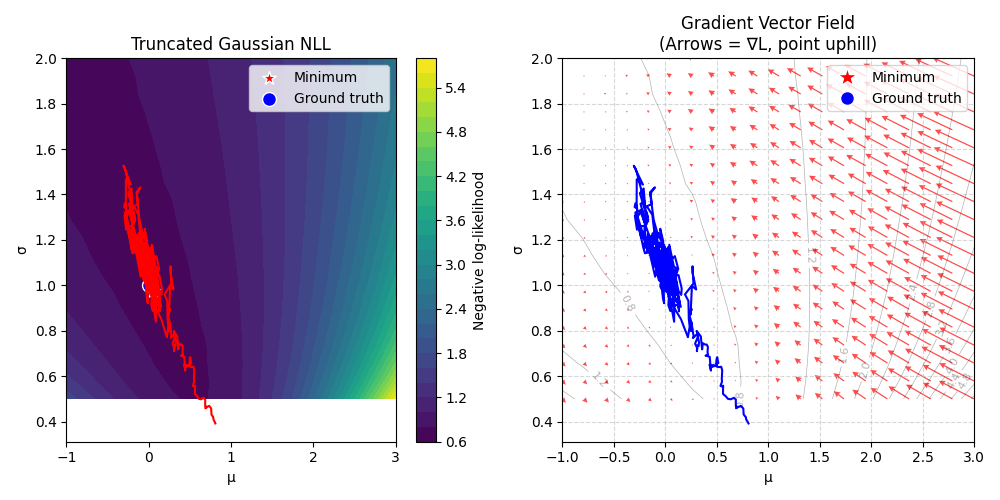

In [71]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=False)
sampler = PreSampler(dims, )
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
MU_GRAD = np.zeros_like(MU)
SIGMA_GRAD = ch.zeros_like(SIGMA) 
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loc = MU[i, j][...,None]
        loss, T_grad, v_grad = trunc_nll(phi, loc, var, data, known_cov=False, sampler=sampler)
        Z[i, j] = loss
        MU_GRAD[i, j] = T_grad.item()
        SIGMA_GRAD[i, j] = v_grad.item()
        
# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")
print(f"\nLoss at ground truth: {trunc_nll(phi, true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(phi, true_mu, true_var, data)[0] - min_loss:.3f}")        
        
fig = plt.figure(figsize=(10, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(121)
cp = ax1.contourf(MU, SIGMA, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")
# surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
#                        linewidth=0, antialiased=True)
ax1.scatter([min_mu], [min_sigma], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_mu.item()], [true_var.sqrt().item()], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_title("Truncated Gaussian NLL")
ax1.set_xlabel("μ")
ax1.set_ylabel("σ")
ax1.legend()
ax1.legend()

param_history = truncated.trainer.param_history 

T = param_history[:,0]
v = param_history[:,1]

SIGMA_ = (1/T[...,None])
MU_ = SIGMA_ * v[...,None]

SIGMA_ = SIGMA_ * emp_var
MU_ = MU_ * (emp_var ** .5) + emp_loc

ax1.plot(MU_.detach(), SIGMA_.detach(), color='red')

ax2 = fig.add_subplot(122)

# Plot quiver
Q = ax2.quiver(MU, SIGMA, MU_GRAD, SIGMA_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax2.contour(MU, SIGMA, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax2.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax2.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

ax2.plot(MU_.detach(), SIGMA_.detach(), color='blue')


plt.tight_layout()
plt.show()

In [72]:
truncated.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.06561000000000002
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [73]:
param_history = truncated.trainer.param_history 


T = param_history[:,0]
v = param_history[:,1]
SIGMA = (1/T[...,None])
MU = SIGMA * v[...,None]

SIGMA = SIGMA * emp_var
MU = MU * (emp_var ** .5) + emp_loc

In [161]:
loss_history = truncated.trainer.loss_history
ch.argmin(loss_history)

tensor(171)

In [202]:
truncated.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.1
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [201]:
argmin = ch.argmin(ch.abs(0 - MU_))
MU_[argmin], SIGMA_[argmin]

(tensor([-0.0043]), tensor([0.9805]))

In [163]:
best_params = param_history[461]

best_var, best_mu = best_params[0], best_params[1]

best_sigma = 1/best_var

best_loc = best_sigma*best_mu

best_sigma * emp_var, best_loc * (emp_var ** .5) + emp_loc

(tensor([0.8831]), tensor([0.1193]))

<IPython.core.display.Javascript object>


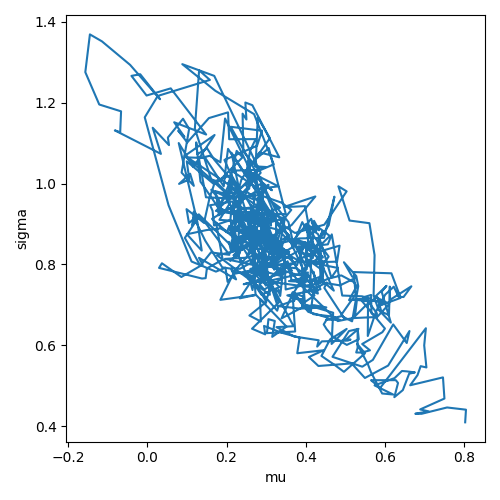

In [88]:
param_history, loss_history = truncated.trainer.param_history, truncated.trainer.loss_history


fig = plt.figure(figsize=(5, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(111)
# surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
#                        linewidth=0, antialiased=True)
# ax1.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
#            label='Minimum', marker='*', edgecolors='white')
# ax1.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
#            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
# ax1.set_xlabel('μ')
# ax1.set_ylabel('σ')
# ax1.set_zlabel('Negative Log-Likelihood')
# ax1.set_title('3D Loss Landscape')
# ax1.legend()

ax1.plot(MU, SIGMA)
ax1.set_xlabel('mu')
ax1.set_ylabel('sigma')


plt.tight_layout()
plt.show()

In [90]:
MU

tensor([0.3301])

In [85]:
emp_loc

tensor([0.8317])

In [ ]:
# Vary mu[0] and sigma[0], fix others
mu0_vals = ch.linspace(true_mu[0] - 2, true_mu[0] + 2, 30)
sigma0_vals = ch.linspace(0.5, 2.0, 30)
MU0, SIGMA0 = ch.meshgrid(mu0_vals, sigma0_vals)

Z = np.zeros((len(sigma0_vals), len(mu0_vals)))
GRAD_MU0 = np.zeros_like(Z)
GRAD_SIGMA0 = np.zeros_like(Z)

for i in range(len(sigma0_vals)):
    for j in range(len(mu0_vals)):
        # Build full mu and Sigma
        mu = true_mu.clone()
        mu[0] = MU0[i, j]
        
        sigma = true_sigma.clone()
        sigma[0] = SIGMA0[i, j]
        Sigma = ch.diag(sigma ** 2)
        
        loss, grad = trunc_nll(mu, Sigma, data, known_cov=False)
        Z[i, j] = loss
        
        # Extract ∂L/∂μ₀ and ∂L/∂σ₀
        dL_dv0 = grad[dims*dims + 0]           # ∂L/∂v₀
        dL_dT00 = grad[0]                      # ∂L/∂T₀₀ (since T is diagonal, T₀₀ is first)
        
        T00 = 1.0 / (sigma[0] ** 2)
        dL_dmu0 = dL_dv0 * T00
        dL_dsigma0 = dL_dT00 * (-2.0 / (sigma[0] ** 3))
        
        GRAD_MU0[i, j] = dL_dmu0
        GRAD_SIGMA0[i, j] = dL_dsigma0